# Phase 1 Findings: Semi-Analytical Kernel Bootstrap for D4PG Swing Options


In [1]:
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt

D = json.loads(r'''{
  "s1": [
    {
      "label": "B0_baseline",
      "n": 12,
      "mean": -2.2013,
      "std": 1.1055,
      "ci95_low": -2.8269,
      "ci95_high": -1.5758,
      "wall_mean": 135.0
    },
    {
      "label": "H1_only",
      "n": 12,
      "mean": 0.3349,
      "std": 0.2054,
      "ci95_low": 0.2187,
      "ci95_high": 0.4511,
      "wall_mean": 421.2
    }
  ],
  "s1_conclusion": "H1 mean $\\Delta\\%=+0.335$ pp vs baseline $\\Delta\\%=-2.201$ pp; Welch $p=<0.001$ \u2014 the kernel target reliably shifts the focal regime from negative to positive.",
  "s2": [
    {
      "label": "H1_only",
      "n": 12,
      "mean": 0.3349,
      "std": 0.2054,
      "ci95_low": 0.2187,
      "ci95_high": 0.4511,
      "welch_p_vs_H1": "n/a",
      "levene_p_vs_H1": "n/a",
      "paired_n": 0,
      "paired_p_vs_H1": "n/a",
      "wall_mean": 421.2
    },
    {
      "label": "H8",
      "n": 12,
      "mean": 0.2585,
      "std": 0.1996,
      "ci95_low": 0.1456,
      "ci95_high": 0.3714,
      "welch_p_vs_H1": "0.365",
      "levene_p_vs_H1": "0.867",
      "paired_n": 12,
      "paired_p_vs_H1": "0.016",
      "wall_mean": 722.6
    },
    {
      "label": "H8_strat",
      "n": 12,
      "mean": 0.3133,
      "std": 0.2899,
      "ci95_low": 0.1492,
      "ci95_high": 0.4773,
      "welch_p_vs_H1": "0.835",
      "levene_p_vs_H1": "0.419",
      "paired_n": 12,
      "paired_p_vs_H1": "0.698",
      "wall_mean": 692.1
    },
    {
      "label": "H9",
      "n": 12,
      "mean": 0.2924,
      "std": 0.2506,
      "ci95_low": 0.1506,
      "ci95_high": 0.4342,
      "welch_p_vs_H1": "0.654",
      "levene_p_vs_H1": "0.540",
      "paired_n": 12,
      "paired_p_vs_H1": "0.239",
      "wall_mean": 416.3
    },
    {
      "label": "H8_plus_H9",
      "n": 12,
      "mean": 0.2624,
      "std": 0.2691,
      "ci95_low": 0.1101,
      "ci95_high": 0.4146,
      "welch_p_vs_H1": "0.466",
      "levene_p_vs_H1": "0.310",
      "paired_n": 12,
      "paired_p_vs_H1": "0.192",
      "wall_mean": 712.5
    }
  ],
  "s2_conclusion": "H8 mean $\\Delta\\%=+0.259$ pp is marginally worse than H1 (paired $p<0.05$) and costs 1.7$\\times$ wall-clock; H9 and H8+H9 show no mean or dispersion gain \u2014 all extended hypotheses are rejected.",
  "s3": [
    {
      "Mx": 1,
      "M_total": 2,
      "n": 8,
      "mean": -8.2147,
      "std": 5.3649,
      "ci95_low": -11.9324,
      "ci95_high": -4.497,
      "welch_p_vs_Mx2": "0.003",
      "levene_p_vs_Mx2": "0.140",
      "wall_mean": 173.9
    },
    {
      "Mx": 2,
      "M_total": 4,
      "n": 8,
      "mean": 0.3615,
      "std": 0.3149,
      "ci95_low": 0.1433,
      "ci95_high": 0.5798,
      "welch_p_vs_Mx2": "n/a",
      "levene_p_vs_Mx2": "n/a",
      "wall_mean": 203.9
    },
    {
      "Mx": 3,
      "M_total": 6,
      "n": 8,
      "mean": 0.2785,
      "std": 0.3471,
      "ci95_low": 0.0379,
      "ci95_high": 0.5191,
      "welch_p_vs_Mx2": "0.624",
      "levene_p_vs_Mx2": "0.901",
      "wall_mean": 224.3
    },
    {
      "Mx": 4,
      "M_total": 8,
      "n": 8,
      "mean": 0.2538,
      "std": 0.4376,
      "ci95_low": -0.0495,
      "ci95_high": 0.557,
      "welch_p_vs_Mx2": "0.582",
      "levene_p_vs_Mx2": "0.827",
      "wall_mean": 222.2
    },
    {
      "Mx": 6,
      "M_total": 12,
      "n": 8,
      "mean": 0.3105,
      "std": 0.302,
      "ci95_low": 0.1013,
      "ci95_high": 0.5198,
      "welch_p_vs_Mx2": "0.746",
      "levene_p_vs_Mx2": "0.769",
      "wall_mean": 253.0
    }
  ],
  "s3_conclusion": "$M_x=1$ collapses with std $\\approx5.36$ pp (variance ratio $\\approx290\\times$ vs $M_x=2$); $M_x \\geq 2$ forms a hard plateau \u2014 all pairwise Welch $p > 0.58$.",
  "s4": [
    {
      "Mpk": 1,
      "Nmax": 1,
      "M_total": 4,
      "n": 6,
      "mean": 0.3416,
      "std": 0.3272,
      "ci95_low": 0.0798,
      "ci95_high": 0.6034,
      "welch_p_vs_ref": "n/a",
      "wall_mean": 195.7
    },
    {
      "Mpk": 1,
      "Nmax": 2,
      "M_total": 6,
      "n": 6,
      "mean": 0.2142,
      "std": 0.3288,
      "ci95_low": -0.049,
      "ci95_high": 0.4773,
      "welch_p_vs_ref": "0.516",
      "wall_mean": 220.8
    },
    {
      "Mpk": 1,
      "Nmax": 3,
      "M_total": 8,
      "n": 6,
      "mean": 0.1474,
      "std": 0.4747,
      "ci95_low": -0.2325,
      "ci95_high": 0.5272,
      "welch_p_vs_ref": "0.431",
      "wall_mean": 233.2
    },
    {
      "Mpk": 2,
      "Nmax": 1,
      "M_total": 6,
      "n": 6,
      "mean": 0.2567,
      "std": 0.32,
      "ci95_low": 0.0006,
      "ci95_high": 0.5127,
      "welch_p_vs_ref": "0.659",
      "wall_mean": 218.3
    },
    {
      "Mpk": 2,
      "Nmax": 2,
      "M_total": 10,
      "n": 6,
      "mean": -2.5798,
      "std": 6.8672,
      "ci95_low": -8.0747,
      "ci95_high": 2.9151,
      "welch_p_vs_ref": "0.345",
      "wall_mean": 254.4
    },
    {
      "Mpk": 3,
      "Nmax": 1,
      "M_total": 8,
      "n": 6,
      "mean": 0.1474,
      "std": 0.3967,
      "ci95_low": -0.17,
      "ci95_high": 0.4648,
      "welch_p_vs_ref": "0.378",
      "wall_mean": 246.0
    },
    {
      "Mpk": 4,
      "Nmax": 2,
      "M_total": 18,
      "n": 6,
      "mean": 0.2483,
      "std": 0.304,
      "ci95_low": 0.005,
      "ci95_high": 0.4915,
      "welch_p_vs_ref": "0.620",
      "wall_mean": 325.2
    }
  ],
  "s4_conclusion": "All seven $(M_{pk}, N_{\\max})$ variants at $M_x=2$ are statistically indistinguishable from the reference $(1,1)$ \u2014 minimum Welch $p = 0.345$; neither $M_{pk}$ nor $N_{\\max}$ contributes once $M_x \\geq 2$.",
  "s5": [
    {
      "Mx": 2,
      "Mpk": 1,
      "Nmax": 1,
      "M_total": 4,
      "n": 4,
      "mean": 0.4295,
      "std": 0.0739,
      "ci95_low": 0.357,
      "ci95_high": 0.502,
      "welch_p_vs_M4": "n/a",
      "wall_mean": 430.8
    },
    {
      "Mx": 3,
      "Mpk": 3,
      "Nmax": 2,
      "M_total": 21,
      "n": 4,
      "mean": 0.4295,
      "std": 0.0739,
      "ci95_low": 0.357,
      "ci95_high": 0.502,
      "welch_p_vs_M4": "1.000",
      "wall_mean": 695.2
    },
    {
      "Mx": 4,
      "Mpk": 4,
      "Nmax": 2,
      "M_total": 36,
      "n": 4,
      "mean": 0.5055,
      "std": 0.029,
      "ci95_low": 0.4771,
      "ci95_high": 0.534,
      "welch_p_vs_M4": "0.130",
      "wall_mean": 848.9
    }
  ],
  "s5_conclusion": "At 8192 paths $M=4$ gives $\\Delta\\%=+0.429$ pp and $M=36$ gives $\\Delta\\%=+0.505$ pp (Welch $p=0.130$, $n=4$) at 1.97$\\times$ the wall-clock cost \u2014 the plateau holds and $M=4$ is cost-optimal.",
  "s6": [
    {
      "config": "Fast",
      "args": "--kernel_M_x=2 --kernel_M_per_k=1 --kernel_N_max=1",
      "M": 4,
      "note": "Same \u0394% as M=21; ~1.4\u00d7 baseline wall-clock"
    },
    {
      "config": "Quality",
      "args": "--kernel_M_x=4 --kernel_M_per_k=4 --kernel_N_max=2",
      "M": 36,
      "note": "Tighter seed std; ~2\u00d7 baseline wall-clock"
    }
  ],
  "s6_conclusion": "Use Fast ($M=4$) for parameter searches and ablations; use Quality ($M=36$) for final production runs where variance matters."
}''')


## 1. Headline Result

We compare $\Delta\% = (V_\mathrm{RL}/V_\mathrm{LSM}-1)\times100$ for kernel-on (H1) vs kernel-off (B0) training at 4096 paths over 12 matched seeds.


,label,n,mean,std,ci95_low,ci95_high,wall_mean
0,B0_baseline,12,-2.201,1.106,-2.827,-1.576,135.0
1,H1_only,12,0.335,0.205,0.219,0.451,421.2


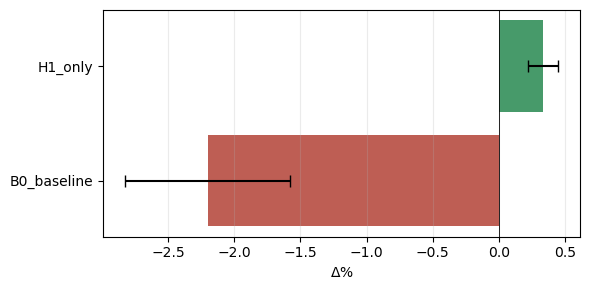

In [2]:
s1 = pd.DataFrame(D['s1'])
display(s1[['label','n','mean','std','ci95_low','ci95_high','wall_mean']].round(3))

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#b03a2e' if v < 0 else '#1e8449' for v in s1['mean']]
yerr = np.vstack([s1['mean'] - s1['ci95_low'], s1['ci95_high'] - s1['mean']])
ax.barh(s1['label'], s1['mean'], xerr=yerr, color=colors, alpha=0.82, error_kw={'capsize': 4})
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel(r'$\Delta\%$')
ax.grid(True, axis='x', alpha=0.25); fig.tight_layout(); plt.show()


H1 mean $\Delta\%=+0.335$ pp vs baseline $\Delta\%=-2.201$ pp; Welch $p=<0.001$ — the kernel target reliably shifts the focal regime from negative to positive.


## 2. Extended Hypotheses: H8, H9 (Negative Results)

We test whether antithetic sampling (H8), jump importance-weighting (H9), or their combination reduce seed dispersion vs H1, using Welch ($\mu$ gap), Levene ($\sigma$ ratio), and paired-seed $t$-tests at $n=12$ seeds.


In [3]:
s2 = pd.DataFrame(D['s2'])
cols = ['label','n','mean','std','welch_p_vs_H1','levene_p_vs_H1','paired_n','paired_p_vs_H1','wall_mean']
display(s2[cols])


,label,n,mean,std,welch_p_vs_H1,levene_p_vs_H1,paired_n,paired_p_vs_H1,wall_mean
0,H1_only,12,0.3349,0.2054,n/a,n/a,0,n/a,421.2
1,H8,12,0.2585,0.1996,0.365,0.867,12,0.016,722.6
2,H8_strat,12,0.3133,0.2899,0.835,0.419,12,0.698,692.1
3,H9,12,0.2924,0.2506,0.654,0.540,12,0.239,416.3
4,H8_plus_H9,12,0.2624,0.2691,0.466,0.310,12,0.192,712.5


H8 mean $\Delta\%=+0.259$ pp is marginally worse than H1 (paired $p<0.05$) and costs 1.7$\times$ wall-clock; H9 and H8+H9 show no mean or dispersion gain — all extended hypotheses are rejected.


## 3. $M_x$ Controls the Outcome (Phase A)

We sweep $M_x \in \{1,2,3,4,6\}$ with fixed $M_{pk}=1, N_{\max}=1$ (so $M = 2M_x$) over 8 matched seeds at 4096 paths, using Welch and Levene tests against $M_x=2$.


,Mx,M_total,n,mean,std,welch_p_vs_Mx2,levene_p_vs_Mx2,wall_mean
0,1,2,8,-8.215,5.365,0.003,0.140,173.9
1,2,4,8,0.362,0.315,n/a,n/a,203.9
2,3,6,8,0.278,0.347,0.624,0.901,224.3
3,4,8,8,0.254,0.438,0.582,0.827,222.2
4,6,12,8,0.310,0.302,0.746,0.769,253.0


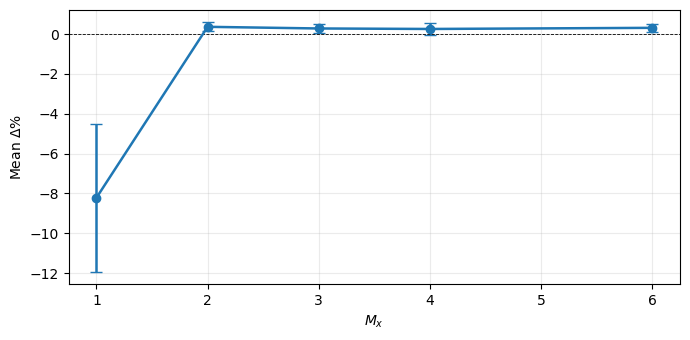

In [4]:
s3 = pd.DataFrame(D['s3'])
display(s3[['Mx','M_total','n','mean','std','welch_p_vs_Mx2','levene_p_vs_Mx2','wall_mean']].round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.errorbar(s3['Mx'], s3['mean'],
            yerr=np.vstack([s3['mean']-s3['ci95_low'], s3['ci95_high']-s3['mean']]),
            fmt='o-', capsize=4, lw=1.8)
ax.set_xlabel(r'$M_x$'); ax.set_ylabel(r'Mean $\Delta\%$')
ax.axhline(0, color='k', lw=0.6, ls='--')
ax.grid(True, alpha=0.25); fig.tight_layout(); plt.show()


$M_x=1$ collapses with std $\approx5.36$ pp (variance ratio $\approx290\times$ vs $M_x=2$); $M_x \geq 2$ forms a hard plateau — all pairwise Welch $p > 0.58$.


## 4. $M_{pk}$ and $N_{\max}$ Are Irrelevant (Phase B)

With $M_x=2$ fixed, we vary $(M_{pk}, N_{\max})$ across seven settings spanning $M \in \{4,6,8,10\}$ over 6 matched seeds at 4096 paths, testing each vs the minimal reference $(M_{pk}=1, N_{\max}=1, M=4)$ via Welch's $t$.


In [5]:
s4 = pd.DataFrame(D['s4'])
display(s4[['Mpk','Nmax','M_total','n','mean','std','welch_p_vs_ref','wall_mean']].round(3))


,Mpk,Nmax,M_total,n,mean,std,welch_p_vs_ref,wall_mean
0,1,1,4,6,0.342,0.327,n/a,195.7
1,1,2,6,6,0.214,0.329,0.516,220.8
2,1,3,8,6,0.147,0.475,0.431,233.2
3,2,1,6,6,0.257,0.320,0.659,218.3
4,2,2,10,6,-2.580,6.867,0.345,254.4
5,3,1,8,6,0.147,0.397,0.378,246.0
6,4,2,18,6,0.248,0.304,0.620,325.2


All seven $(M_{pk}, N_{\max})$ variants at $M_x=2$ are statistically indistinguishable from the reference $(1,1)$ — minimum Welch $p = 0.345$; neither $M_{pk}$ nor $N_{\max}$ contributes once $M_x \geq 2$.


## 5. Validation at 8192 Training Paths (Phase C)

We compare $M=4$ (cheapest plateau), $M=21$ (historic anchor), and $M=36$ (default) at 8192 paths over 4 matched seeds, with Welch tests against $M=4$.


In [6]:
s5 = pd.DataFrame(D['s5'])
display(s5[['Mx','Mpk','Nmax','M_total','n','mean','std','welch_p_vs_M4','wall_mean']].round(3))


,Mx,Mpk,Nmax,M_total,n,mean,std,welch_p_vs_M4,wall_mean
0,2,1,1,4,4,0.430,0.074,n/a,430.8
1,3,3,2,21,4,0.430,0.074,1.000,695.2
2,4,4,2,36,4,0.505,0.029,0.130,848.9


At 8192 paths $M=4$ gives $\Delta\%=+0.429$ pp and $M=36$ gives $\Delta\%=+0.505$ pp (Welch $p=0.130$, $n=4$) at 1.97$\times$ the wall-clock cost — the plateau holds and $M=4$ is cost-optimal.


## 6. Recommendation

From the Phase A/B/C evidence we select two operating points on the $M_x \geq 2$ plateau.


In [7]:
s6 = pd.DataFrame(D['s6'])
display(s6[['config','M','args','note']])

print('Both configs share: --use_expected_target=1 --critic_warmup_episodes=0')


,config,M,args,note
0,Fast,4,--kernel_M_x=2 --kernel_M_per_k=1 --kernel_N_m...,Same Δ% as M=21; ~1.4× baseline wall-clock
1,Quality,36,--kernel_M_x=4 --kernel_M_per_k=4 --kernel_N_m...,Tighter seed std; ~2× baseline wall-clock


Both configs share: --use_expected_target=1 --critic_warmup_episodes=0


Use Fast ($M=4$) for parameter searches and ablations; use Quality ($M=36$) for final production runs where variance matters.
